<a href="https://colab.research.google.com/github/Rogerio-mack/IMT_CD_2026/blob/main/IMT_CD_PSUB1_2026_solucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<head>
  <meta name="author" content="Rogério de Oliveira">
  <meta institution="author" content="ITM">
</head>

<img src="https://maua.br/images/selo-60-anos-maua.svg" width=300, align="right">
<!-- <h1 align=left><font size = 6, style="color:rgb(200,0,0)"> optional title </font></h1> -->




# **PSUB1 - ECM514 Ciência de Dados**

In [1]:
#@markdown Nome **COMPLETO** e RA

Nome = 'Anna Karenina' #@param {type:"string"}
RA = '22.01164-0' #@param {type:"string"}
#@markdown

suffix_file = RA.replace('.','')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

path = 'https://github.com/Rogerio-mack/work/raw/main/data/'

#@markdown Salve o seu notebook com **IMT_CD_PSUB1_2026_\<seu_nome\>.ipynb**

#@markdown Execute esta célula para prosseguir.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# **CASE: Crise Climática, Variação do Nível do Mar**

A série abaixo simula as **variações do nível do mar** ao longo das últimas décadas evidenciando um aumento de quase 3m devido a crise climática.

A partir desses dados, crie um modelo ARIMA para prever **aumento do nível do mar** daqui 5 anos.

In [3]:
def run_model(ar_params = np.array([0.7, -0.4, 0.1]),
              ma_params = np.array([0.4, 0.2]),
              order=[3,3,2],
              start_date = '1973-12-01',
              year = 1972,
              seed= 1,
              d = 1):
# Gera série simulada

  from statsmodels.tsa.arima_process import arma_generate_sample
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  np.random.seed(seed)

  # Definir os parâmetros p, d, q
  p = 2
  # d = 2
  q = 3

  # Coeficientes AR (p=3). Os coeficientes são negativos na representação usual de statsmodels (y_t = c + AR_coef * y_{t-k} + ...)
  # Para um processo estacionário, as raízes devem estar fora do círculo unitário. Abaixo, exemplos de coeficientes.
  # ar_params = np.array([0.7, -0.4, 0.1]) # Exemplo: phi_1=0.7, phi_2=-0.4, phi_3=0.2
  # ma_params = np.array([0.4, 0.2])    # Exemplo: theta_1=0.5, theta_2=0.3

  # Incluir o coeficiente 1 para o termo y_t e termo de erro e_t
  ar = np.r_[1, -ar_params]
  ma = np.r_[1, ma_params]

  # Gerar o componente ARMA(p,q) sem o differencing (d=0)
  # O número de amostras precisa ser maior para permitir o differencing inverso
  # do total de meses (2026-1962+1)*12 = 804 meses.
  nobs = ((2025 - year + 1) * 12) + 1 + d # Adicionar 'd' para compensar o cumsum inicial
  simulated_arma = arma_generate_sample(ar=ar, ma=ma, nsample=nobs, scale=0.6)
  # simulated_arma = simulated_arma + arma_generate_sample(ar=(0,0,0), ma=ma, nsample=nobs, scale=0.5)

  # Aplicar differencing inverso 'd' vezes (cumsum)
  simulated_arima = simulated_arma
  for _ in range(d):
      simulated_arima = np.cumsum(simulated_arima)

  # Criar o índice de data mensal
  # start_date = '1973-12-01'
  end_date = '2025-12-31'
  dates = pd.date_range(start=start_date, end=end_date, freq='MS')

  # Ajustar o tamanho da série se necessário (caso o número de observações gerado seja ligeiramente diferente do desejado após cumsum)
  # Devemos ter len(simulated_arima) == len(dates)
  if len(simulated_arima) > len(dates):
      simulated_arima = simulated_arima[-len(dates):]
  elif len(simulated_arima) < len(dates):
      # Isso não deve acontecer se nobs for calculado corretamente, mas é um safety check
      raise ValueError("Not enough simulated data points.")

  # Criar a série Pandas
  simulated_ts = pd.Series(simulated_arima, index=dates, name='Simulated_ARIMA_Series')

  simulated_ts = simulated_ts.diff().dropna()

  # Visualizar a série temporal gerada
  plt.figure(figsize=(8, 4))
  plt.plot(simulated_ts)
  plt.title(f'Variação mensal do nível do mar (mm)')
  plt.xlabel('Data')
  plt.ylabel('Valor')
  # plt.grid(True)
  plt.show()

  # display(simulated_ts.head())
  # display(simulated_ts.tail())

  ts = pd.DataFrame(simulated_ts).copy()
  ts = ts / 10
  ts.columns = ['ocean_variation']
  ts['year'] = ts.index.year
  ts['month_name'] = ts.index.month_name()
  ts['month'] = ts.index.month
  ts.reset_index(drop=True,inplace=True)
  ts.index = pd.to_datetime(ts[['year', 'month']].assign(day=1)) + pd.offsets.MonthEnd(0)
  ts['day'] = ts.index.day
  ts.drop(columns=['month','day'],inplace=True)
  ts.reset_index(drop=True,inplace=True)
  display(ts)

  ts.to_csv('ts_ocean.csv',index=None)




  # plt.figure(figsize=(8, 4))
  # plt.plot(ts)
  # plt.title(f'Evolução do nível do mar (mm)')
  # plt.xlabel('Data')
  # plt.ylabel('Valor')
  # plt.grid(True)
  # plt.show()

  # display(ts)

  return ts


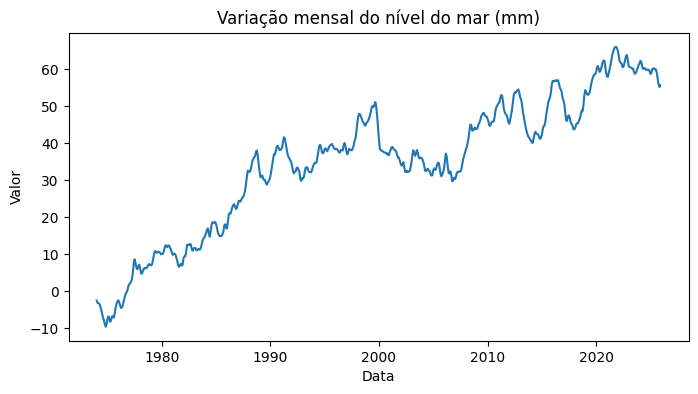

,ocean_variation,year,month_name
0,-0.260142,1974,January
1,-0.327301,1974,February
2,-0.330692,1974,March
3,-0.350572,1974,April
4,-0.413499,1974,May
...,...,...,...
619,5.910776,2025,August
620,5.737703,2025,September
621,5.590138,2025,October
622,5.514393,2025,November


In [4]:
ts = run_model(ar_params = np.array([0.65, -0.4, 0.22]),
              ma_params = np.array([0.4, 0.12]),
              order=[3,2,2],
              start_date = '1973-12-01',
              year = 1972,
              seed= 1,
              d = 2)



In [5]:
ts = pd.read_csv(path + 'ts_ocean.csv')
ts.head()

,ocean_variation,year,month_name
0,-0.260142,1974,January
1,-0.327301,1974,February
2,-0.330692,1974,March
3,-0.350572,1974,April
4,-0.413499,1974,May


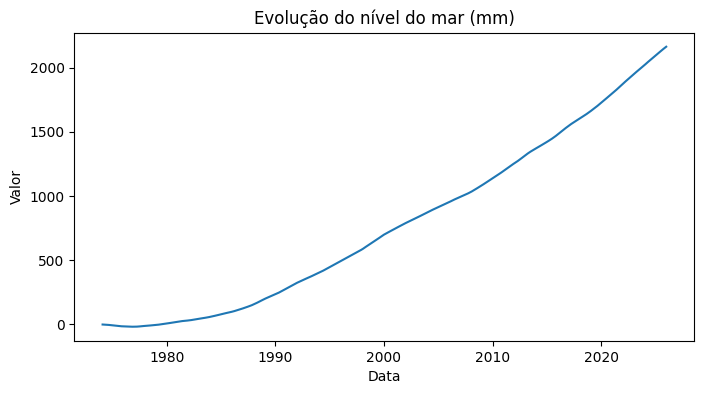

,ocean_accum
1974-01-31,-0.260142
1974-02-28,-0.587443
1974-03-31,-0.918135
1974-04-30,-1.268707
1974-05-31,-1.682205
...,...
2025-08-31,2139.719295
2025-09-30,2145.456998
2025-10-31,2151.047136
2025-11-30,2156.561529


In [6]:
month_mapping = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
ts['month'] = ts['month_name'].map(month_mapping)

ts.index = pd.to_datetime(ts[['year', 'month']].assign(day=1)) + pd.offsets.MonthEnd(0)
ts.index = pd.DatetimeIndex(ts.index.values,freq=ts.index.inferred_freq)

ts.drop(columns=['month','year','month_name'],inplace=True)
ts.ocean_variation = ts.ocean_variation.cumsum()
ts.columns = ['ocean_accum']

plt.figure(figsize=(8, 4))
plt.plot(ts)
plt.title(f'Evolução do nível do mar (mm)')
plt.xlabel('Data')
plt.ylabel('Valor')
# plt.grid(True)
plt.show()

display(ts)



## Q1. (1.5) Obtenha os parâmetros $(p,d,q)$ do modelo ARIMA

Considere somente $lags \le 6$ e correlações claramente significativas (se necessário, desconsidere correlações na borda da faixa de significância).





### $d$, Estacionariedade

In [7]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series)
    print(f'Teste ADF:')
    print(f'Estatística ADF: {result[0]}')
    print(f'Valor-p: {result[1]}')
    if result[1] <= 0.05:
        print('A série temporal é estacionária (rejeita H0)')
    else:
        print('A série temporal não é estacionária (falha em rejeitar H0)')
    return result[1]

print('\n d=0')
adf_test(ts)

print('\n d=1')
adf_test(ts.diff().dropna())

print('\n d=2')
adf_test(ts.diff().diff().dropna())




 d=0
Teste ADF:
Estatística ADF: 1.8528252512888475
Valor-p: 0.9984482284590621
A série temporal não é estacionária (falha em rejeitar H0)

 d=1
Teste ADF:
Estatística ADF: -1.9486798750475
Valor-p: 0.3095181850248083
A série temporal não é estacionária (falha em rejeitar H0)

 d=2
Teste ADF:
Estatística ADF: -9.901419695952205
Valor-p: 3.3499963819211823e-17
A série temporal é estacionária (rejeita H0)


np.float64(3.3499963819211823e-17)

### **$p, q$** Auto-correlação e Correlação Parcial, ACF e PACF



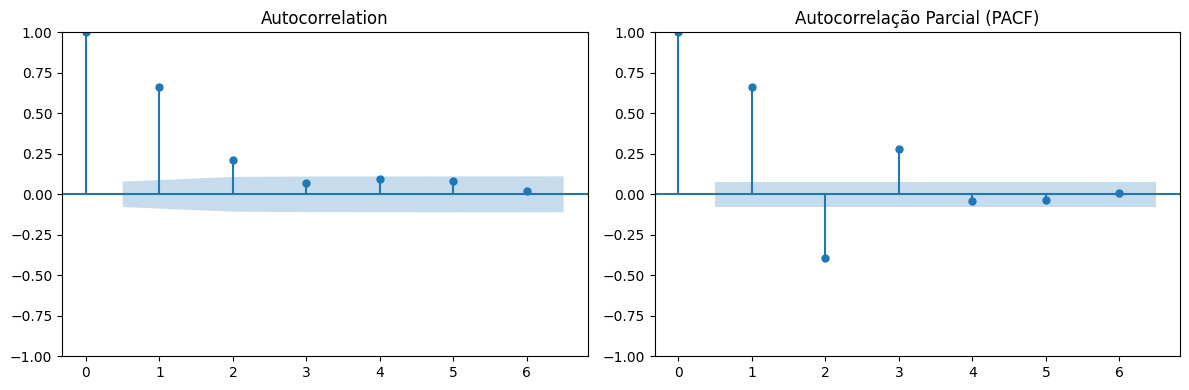

In [8]:
fig, [ax1, ax2] = plt.subplots(1,2,figsize=(12, 4))

plot_acf(ts.diff().diff().dropna(), lags=6, ax=ax1)
ax2.set_title('Autocorrelação (ACF)')

plot_pacf(ts.diff().diff().dropna(), lags=6, ax=ax2)
ax2.set_title('Autocorrelação Parcial (PACF)')

plt.tight_layout()
plt.show()



$$ARIMA(3,2,2)$$


In [2]:
#@markdown #### Q1. Informe os valores obtidos dos parâmetros p, d, q de acordo com a sua análise.
#@markdown $p$ (termos do modelo AR) =
Q1A = 3 #@param {type:"number"}

#@markdown $d$ (diferenciação) =
Q1B = 2 #@param {type:"number"}

#@markdown $q$ (termos do modelo MA) =
Q1C = 2 #@param {type:"number"}

Q1 = {}
Q1['Q1A. p ='] = Q1A
Q1['Q1B. d ='] = Q1B
Q1['Q1C. q ='] = Q1C

print('Suas respostas:')
for k,v in Q1.items():
  print(f'{k} {v}')

Suas respostas:
Q1A. p = 3
Q1B. d = 2
Q1C. q = 2


## Q2. (1.5) Modelo 1

Crie um modelo com ARIMA com base nos parâmetros obtidos na questão anterior e responda as questões a seguir.

Empregue `fit(method_kwargs={'maxiter':100})` para aumentar o número de iterações (o padrão é 50). Isso evita a parada do ajuste antes da convergência e a mensagem de alerta referente a isso.

In [10]:
order = (3,2,2)

model = ARIMA(ts, order=order).fit(method_kwargs={'maxiter':100})

print(model.summary())

                               SARIMAX Results                                
Dep. Variable:            ocean_accum   No. Observations:                  624
Model:                 ARIMA(3, 2, 2)   Log Likelihood                 871.317
Date:                Thu, 27 Aug 2026   AIC                          -1730.633
Time:                        14:52:45   BIC                          -1704.035
Sample:                    01-31-1974   HQIC                         -1720.296
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2970      0.288      1.032      0.302      -0.267       0.861
ar.L2         -0.2125      0.185     -1.149      0.250      -0.575       0.150
ar.L3          0.1364      0.092      1.481      0.1

In [11]:
from sklearn.metrics import mean_squared_error
from math import sqrt
import numpy as np

# Get the fitted values from the model
fitted_values = model.fittedvalues

# Align the original series 'ts' with the fitted_values index
# The fitted_values start from the point where differencing allows a prediction (after 2 differences, so index 2)
actual_values = ts['ocean_accum'][fitted_values.index]

# Calculate RMSE
rmse = sqrt(mean_squared_error(actual_values, fitted_values))
print(f'RMSE for the model: {rmse:.4f}')

# Calculate MAPE (handle division by zero if actual_values contain zero)
# Using a small epsilon to prevent division by zero for MAPE calculation
epsilon = 1e-10
mape = np.mean(np.abs(actual_values - fitted_values) / np.maximum(np.abs(actual_values), epsilon)) * 100
print(f'MAPE for the model: {mape:.4f} %')

RMSE for the model: 0.0609
MAPE for the model: 0.3294 %


Usando os resíduos...

In [12]:
from sklearn.metrics import mean_squared_error
from math import sqrt
import numpy as np

# Get residuals from the current model (model: ARIMA(0,2,2))
residuals = model.resid

# Calculate RMSE using residuals
rmse_from_resid = sqrt(np.mean(residuals**2))
print(f'RMSE calculado a partir dos resíduos do modelo: {rmse_from_resid:.4f}')

# To calculate MAPE, we still need the actual_values for the denominator
# (residuals = actual_values - fitted_values)
# We'll retrieve actual_values as done previously for consistency

fitted_values = model.fittedvalues
actual_values = ts['ocean_accum'][fitted_values.index]

epsilon = 1e-10
mape_from_resid = np.mean(np.abs(residuals) / np.maximum(np.abs(actual_values), epsilon)) * 100
print(f'MAPE calculado a partir dos resíduos (com valores reais): {mape_from_resid:.4f} %')

RMSE calculado a partir dos resíduos do modelo: 0.0609
MAPE calculado a partir dos resíduos (com valores reais): 0.3294 %


In [13]:
order = (0,2,2)

model = ARIMA(ts, order=order).fit(method_kwargs={'maxiter':100})

print(model.summary())

                               SARIMAX Results                                
Dep. Variable:            ocean_accum   No. Observations:                  624
Model:                 ARIMA(0, 2, 2)   Log Likelihood                 870.954
Date:                Thu, 27 Aug 2026   AIC                          -1735.907
Time:                        14:52:47   BIC                          -1722.608
Sample:                    01-31-1974   HQIC                         -1730.739
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          1.0575      0.035     30.191      0.000       0.989       1.126
ma.L2          0.4202      0.033     12.596      0.000       0.355       0.486
sigma2         0.0036      0.000     18.289      0.0

In [4]:
#@markdown #### Q2. Informe os seguintes dados a partir do modelo obtido:
#@markdown $AIC$ =
Q2A = -1730.633 #@param {type:"number"}

#@markdown $RMSE$ =
Q2B = 0.0609 #@param {type:"number"}

#@markdown $MAPE$ =
Q2C = 0.3294 #@param {type:"number"}

#@markdown Foram estimados **parâmetros não significativos** no seu modelo? **Se sim**, informe aqui os parâmetros do modelo somente com parâmetros significativos. Caso contrário, informe os parâmetros do modelo anterior.
#@markdown
Q2D = "ma.L1 = 1.0575, ma.L2 = 0.4202, sigma2 = 0.0036; (OU ma.L1 = 0.7554, ma.L2 = 0.3255, sigma2 = 0.0035;)" #@param {type:"string"}

Q2 = {}
Q2['Q2A. AIC ='] = Q2A
Q2['Q2B. RMSE ='] = Q2B
Q2['Q2C. MAPE ='] = Q2C
Q2['Q2D. params:'] = Q2D

print('Suas respostas:')
for k,v in Q2.items():
  print(f'{k} {v}')

Suas respostas:
Q2A. AIC = -1730.633
Q2B. RMSE = 0.0609
Q2C. MAPE = 0.3294
Q2D. params: ma.L1 = 1.0575, ma.L2 = 0.4202, sigma2 = 0.0036; (OU ma.L1 = 0.7554, ma.L2 = 0.3255, sigma2 = 0.0035;)


ma.L1 = 1.0575, ma.L2 = 0.4202, sigma2 = 0.0036; esses são os parâmetros do modelo somente com parâmetros significativos

alternativamente aceitei: ma.L1 = 0.7554, ma.L2 = 0.3255, sigma2 = 0.0035; caso não tenha havido entendimento claro da questão

## Q3. (1.5) Best Model e Forecast

Os gráficos ACF e PACF fornecem apenas uma estimativa inicial dos parâmetros do modelo mas não são valores exatos por uma série de motivos (sobreposição de efeitos, precisão numérica, variabilidade amostral etc.). Assim, a ideia é que os parâmetros finais de um modelo estejam ao menos em "torno" dos valores sugeridos pelos gráficos ACF e PACF.

**Varie os parâmetros do modelo, de 0 ao valor sugerido pelos gráficos + 1,**

$$p \in [0, p_0 + 1]$$
$$q \in [0, q_0 + 1]$$

Responda então às perguntas sobre o melhor modelo encontrado e faça uma previsão com esse modelo do aumento do nível que será alcançado em Janeiro de 2030.

<br>

<small>
<b>nota:</b>
eventuais alertas de: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters, ou de ConvergenceWarning podem ser aqui ignorados.

In [15]:
best_aic = np.inf
best_order = None

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model_check = ARIMA(ts, order=(p, 2, q))
            model_check_fit = model_check.fit(method_kwargs={'maxiter':100})
            current_aic = model_check_fit.aic

            if current_aic < best_aic:
                best_aic = current_aic
                best_order = (p, 2, q)
                print(f"Novo melhor AIC: {best_aic:.2f} com ordem: {best_order}")
        except Exception as e:
            print(f"Não foi possível ajustar o modelo ARIMA({p}, 2, {q}). Erro: {e}")
            continue

print(f"\nMelhor modelo ARIMA encontrado: {best_order} com AIC de {best_aic:.2f}")

Novo melhor AIC: -1223.30 com ordem: (0, 2, 0)


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Novo melhor AIC: -1634.28 com ordem: (0, 2, 1)
Novo melhor AIC: -1735.91 com ordem: (0, 2, 2)


/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Melhor modelo ARIMA encontrado: (0, 2, 2) com AIC de -1735.91


In [16]:
order = (0,2,2)

model = ARIMA(ts, order=order).fit(method_kwargs={'maxiter':100})

print(model.summary())

                               SARIMAX Results                                
Dep. Variable:            ocean_accum   No. Observations:                  624
Model:                 ARIMA(0, 2, 2)   Log Likelihood                 870.954
Date:                Thu, 27 Aug 2026   AIC                          -1735.907
Time:                        14:53:10   BIC                          -1722.608
Sample:                    01-31-1974   HQIC                         -1730.739
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          1.0575      0.035     30.191      0.000       0.989       1.126
ma.L2          0.4202      0.033     12.596      0.000       0.355       0.486
sigma2         0.0036      0.000     18.289      0.0

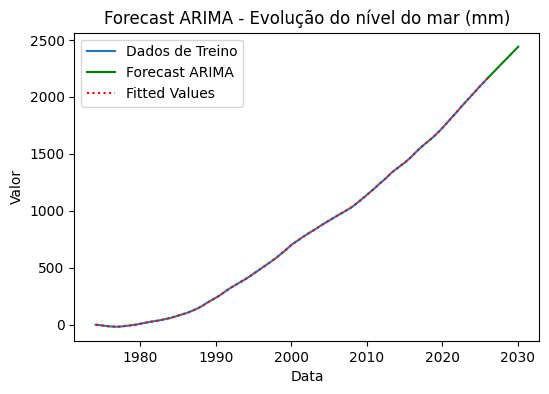

2026-01-31    2167.766071
2026-02-28    2173.440855
2026-03-31    2179.115638
2026-04-30    2184.790422
2026-05-31    2190.465205
2026-06-30    2196.139989
2026-07-31    2201.814772
2026-08-31    2207.489556
2026-09-30    2213.164340
2026-10-31    2218.839123
2026-11-30    2224.513907
2026-12-31    2230.188690
2027-01-31    2235.863474
2027-02-28    2241.538257
2027-03-31    2247.213041
2027-04-30    2252.887824
2027-05-31    2258.562608
2027-06-30    2264.237392
2027-07-31    2269.912175
2027-08-31    2275.586959
2027-09-30    2281.261742
2027-10-31    2286.936526
2027-11-30    2292.611309
2027-12-31    2298.286093
2028-01-31    2303.960877
2028-02-29    2309.635660
2028-03-31    2315.310444
2028-04-30    2320.985227
2028-05-31    2326.660011
2028-06-30    2332.334794
2028-07-31    2338.009578
2028-08-31    2343.684362
2028-09-30    2349.359145
2028-10-31    2355.033929
2028-11-30    2360.708712
2028-12-31    2366.383496
2029-01-31    2372.058279
2029-02-28    2377.733063
2029-03-31  

In [17]:
# forecast = model_fit.forecast(steps=forecast_steps) # Esta é a forma antiga
# Usar predict para um forecast mais robusto com índices
forecast = model.predict(start='2026-01-31', end='2030-01-31')

# Visualizar o forecast
plt.figure(figsize=(6,4))
plt.plot(ts, label='Dados de Treino')
# plt.plot(test.index, test, label='Dados Reais (Teste)', color='orange')
plt.plot(forecast, label='Forecast ARIMA', color='green')
plt.plot(model.fittedvalues[1::], label='Fitted Values', color='red',linestyle=':')

plt.title('Forecast ARIMA - Evolução do nível do mar (mm)')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

print(forecast)


In [18]:
from sklearn.metrics import mean_squared_error
from math import sqrt
import numpy as np

# Get residuals from the current model (model: ARIMA(0,2,2))
residuals = model.resid

# Calculate RMSE using residuals
rmse_from_resid = sqrt(np.mean(residuals**2))
print(f'RMSE calculado a partir dos resíduos do modelo: {rmse_from_resid:.4f}')

# To calculate MAPE, we still need the actual_values for the denominator
# (residuals = actual_values - fitted_values)
# We'll retrieve actual_values as done previously for consistency

fitted_values = model.fittedvalues
actual_values = ts['ocean_accum'][fitted_values.index]

epsilon = 1e-10
mape_from_resid = np.mean(np.abs(residuals) / np.maximum(np.abs(actual_values), epsilon)) * 100
print(f'MAPE calculado a partir dos resíduos (com valores reais): {mape_from_resid:.4f} %')

RMSE calculado a partir dos resíduos do modelo: 0.0609
MAPE calculado a partir dos resíduos (com valores reais): 0.3283 %


In [5]:
#@markdown #### Q3. Informe os seguintes dados a partir do modelo obtido:
#@markdown Parâmetros $(p,d,q)$ do melhor modelo =
Q3A = "(0,2,2)" #@param {type:"string"}

#@markdown $AIC$ =
Q3B = -1735.907 #@param {type:"number"}

#@markdown Valor estimado para Janeiro de 2030 =
Q3C = 2440.15 #@param {type:"number"}

#@markdown O melhor modelo apresenta erro um erro significativamente menor que o seu modelo inicial (primeiro modelo)? Discuta.
#@markdown
Q3D = "Não. A diferença do AIC também é pequena. Como esperado coeficientes excluídos, sendo não significativos, não trazem diferença significativa nos resultados da predição." #@param {type:"string"}

Q3 = {}
Q3['Q3A. (p,d,q) ='] = Q3A
Q3['Q3B. AIC ='] = Q3B
Q3['Q3C. y(Jan 2030) ='] = Q3C
Q3['Q3D. resposta:'] = Q3D

print('Suas respostas:')
for k,v in Q3.items():
  print(f'{k} {v}')

Suas respostas:
Q3A. (p,d,q) = (0,2,2)
Q3B. AIC = -1735.907
Q3C. y(Jan 2030) = 2440.15
Q3D. resposta: Não. A diferença do AIC também é pequena. Como esperado coeficientes excluídos, sendo não significativos, não trazem diferença significativa nos resultados da predição.


# **CASE: Game Analysis**

Os dados abaixo correspondem a uma pesquisa com um jogo de computador empregando diferentes dispositivos e a resposta dos jogadores quanto a desempenho, percepção etc.

Analise os dados e em seguida faça os testes de significância solicitados.

In [7]:
df_games = pd.read_csv(path + 'df_games.csv')
df_post_games_Q = pd.read_csv(path + 'df_post_games_Q.csv')
df_pre_games_Q = pd.read_csv(path + 'df_pre_games_Q.csv')

display(df_games.head())
display(df_post_games_Q.head())
display(df_pre_games_Q.head())

,RA,pontuacao,tempo_obstaculo,tempo_total,device
0,21505616,2,12.44,12.44,skate
1,21505616,13,42.01,54.45,skate
2,21505616,26,49.09,103.54,skate
3,32143621,0,5.45,5.45,skate
4,32143621,3,13.99,19.44,skate


,RA,device,Positive_Experience,Negative_Experience,Tiredness,Returning_to_Reality
0,21505616,joystick,5.000000,1.333333,1.0,2.333333
1,21505616,keyboard,4.666667,2.000000,1.0,2.333333
2,21505616,skate,3.166667,2.833333,1.0,1.666667
3,23513365,joystick,5.000000,1.000000,1.0,2.333333
4,23513365,keyboard,5.000000,1.000000,1.0,2.333333


,Carimbo de data/hora,RA,Data de nascimento,Gênero,Frequência que anda de skate,Frequência que usa jogos de computador,Frequência que usa jogos de console (Xbox / Playstation / Wii),Frequência que usa jogos em dispositivos móveis (smartphone e/ou tablet),Gênero de jogo preferido
0,2023-08-21 16:47:52.279,42118816,2003-06-07,Feminino,Nunca,Regularmente (algumas vezes por semana),Regularmente (algumas vezes por semana),Nunca,"Ação e aventura, RPG, Simulação, Corrida, Estr..."
1,2023-08-22 13:49:56.703,42145333,2000-11-26,Masculino,Raramente (algumas vezes por ano),Regularmente (algumas vezes por semana),Raramente (algumas vezes por ano),Regularmente (algumas vezes por semana),"Ação e aventura, RPG, Estratégia"
2,2023-08-22 14:15:17.455,42326321,2004-11-29,Masculino,Nunca,Ocasionalmente (algumas vezes por mês),Raramente (algumas vezes por ano),Raramente (algumas vezes por ano),Esporte
3,2023-08-22 14:40:49.151,32339623,2004-07-13,Masculino,Nunca,Frequente (todos os dias),Regularmente (algumas vezes por semana),Raramente (algumas vezes por ano),"Ação e aventura, RPG, Estratégia, MOBA"
4,2023-08-22 15:08:53.471,42305535,2005-09-09,Masculino,Nunca,Ocasionalmente (algumas vezes por mês),Nunca,Ocasionalmente (algumas vezes por mês),RPG


## Q4. (1.5) O genêro teve influência no desempenho (pontuação) dos jogadores?

Escolha e aplique o teste adequado para responder a essa pergunta. Verifique o caso geral e por device.

In [22]:
#@markdown #### Q4. Responda a partir do teste aplicado.
#@markdown Teste aplicado e seus parâmetros =
Q4A = "mannwhitneyu()" #@param {type:"string"}

#@markdown $p-value$ (caso geral) =
Q4B = 0.00025 #@param {type:"number"}

#@markdown O genêro teve influência no desempenho (pontuação) dos jogadores? (caso geral)
Q4C = "sim" #@param {type:"string"}

#@markdown Para algum dispositivo o resultado difere do geral? **Se sim**, informe os dispositivos e o p-value para aqueles que divergem do caso geral. Caso contrário informe **None**.
Q4D = "keyboard, p-value = 0.087" #@param {type:"string"}


Q4 = {}
Q4['Q4A. teste ='] = Q4A
Q4['Q4B. p-value ='] = Q4B
Q4['Q4C. resposta: '] = Q4C
Q4['Q4D. resposta: '] = Q4D

print('Suas respostas:')
for k,v in Q4.items():
  print(f'{k} {v}')

Suas respostas:
Q4A. teste = mannwhitneyu()
Q4B. p-value = 0.00025
Q4C. resposta:  sim
Q4D. resposta:  keyboard, p-value = 0.087


In [8]:
from scipy.stats import mannwhitneyu

df = pd.merge(df_games, df_pre_games_Q[['RA','Gênero']], how='inner', on='RA')

stat, p_valor = mannwhitneyu(df[df['Gênero'] == 'Feminino']['pontuacao'], df[df['Gênero'] == 'Masculino']['pontuacao'])

print("Estatística:", stat)
print("Valor p:", p_valor)
if p_valor < 0.05:
    print("Rejeitamos a hipótese nula - valores são estatisticamente diferentes.")
else:
    print("Não rejeitamos a hipótese nula - não há evidências suficientes para afirmar os valores são diferentes.")
print()



Estatística: 7853.0
Valor p: 0.0002557411672916693
Rejeitamos a hipótese nula - valores são estatisticamente diferentes.



In [21]:
from scipy.stats import mannwhitneyu

for d in df_games['device'].unique():
  print(f'Device: {d}')

  df = pd.merge(df_games, df_pre_games_Q[['RA','Gênero']], how='inner', on='RA')

  stat, p_valor = mannwhitneyu(df[ (df['Gênero'] == 'Feminino') & (df.device == d) ]['pontuacao'], df[ (df['Gênero'] == 'Masculino') & (df.device == d)]['pontuacao'])

  print("Estatística:", stat)
  print("Valor p:", p_valor)
  if p_valor < 0.05:
      print("Rejeitamos a hipótese nula - valores são estatisticamente diferentes.")
  else:
      print("Não rejeitamos a hipótese nula - não há evidências suficientes para afirmar os valores são diferentes.")
  print()

Device: skate
Estatística: 727.0
Valor p: 0.003047546798124285
Rejeitamos a hipótese nula - valores são estatisticamente diferentes.

Device: joystick
Estatística: 792.0
Valor p: 0.0020410959936567282
Rejeitamos a hipótese nula - valores são estatisticamente diferentes.

Device: keyboard
Estatística: 871.5
Valor p: 0.08760850621852327
Não rejeitamos a hipótese nula - não há evidências suficientes para afirmar os valores são diferentes.



In [23]:
df.groupby('Gênero').pontuacao.describe()

,count,mean,std,min,25%,50%,75%,max
Gênero,,,,,,,,
Feminino,75.0,8.853333,11.338398,0.0,2.0,4.0,9.5,35.0
Masculino,288.0,15.725694,14.148704,0.0,3.0,9.0,34.0,36.0


In [24]:
df.groupby(['device','Gênero']).pontuacao.describe()

count       mean        std  min   25%   50%   75%   max
device   Gênero                                                             
joystick Feminino    27.0   7.370370   8.454167  0.0   2.0   5.0   9.0  32.0
         Masculino   96.0  16.395833  13.838527  0.0   4.0  11.5  34.0  36.0
keyboard Feminino    24.0  17.375000  14.163064  0.0   4.0  14.0  34.0  35.0
         Masculino   93.0  25.709677  12.632412  0.0  17.0  34.0  34.0  36.0
skate    Feminino    24.0   2.000000   2.206709  0.0   0.0   2.0   3.0   9.0
         Masculino   99.0   5.696970   7.360200  0.0   1.0   3.0   6.5  35.0

## Q5. (1.5) Formule uma pergunta relevante que envolva o teste $\chi^2$ para o conjunto de dados de Game Analysis.

Escolha e aplique o teste adequado para responder a essa pergunta.

In [23]:
#@markdown #### Q5. Responda a partir da pergunta selecionada e do teste aplicado.
#@markdown Qual a sua pergunta?
Q5A = "O Gênero influencia na Frequência que o sujeito usa jogos de computador? " #@param {type:"string"}

#@markdown Quais as variáveis envolvidas?
Q5B = "df_pre_games_Q: ['Gênero'] e ['Frequência que usa jogos de computador']" #@param {type:"string"}

#@markdown $p-value$ obtido no teste $\chi^2$ =
Q5C = 0.0073 #@param {type:"number"}

#@markdown Escreva a sua conclusão do teste? (a resposta à pergunta que formulou)
Q5D = "Sim, o Gênero influencia na Frequência que o sujeito usa jogos de computador." #@param {type:"string"}

Q5 = {}
Q5['Q5A. Sua pergunta ='] = Q5A
Q5['Q5B. Variáveis envolvidas ='] = Q5B
Q5['Q5C. p-value = '] = Q5C
Q5['Q5D. Sua resposta: '] = Q5D

print('Suas respostas:')
for k,v in Q5.items():
  print(f'{k} {v}')

Suas respostas:
Q5A. Sua pergunta = O Gênero influencia na Frequência que o sujeito usa jogos de computador? 
Q5B. Variáveis envolvidas = df_pre_games_Q: ['Gênero'] e ['Frequência que usa jogos de computador']
Q5C. p-value =  0.0073
Q5D. Sua resposta:  Sim, o Gênero influencia na Frequência que o sujeito usa jogos de computador.


In [26]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df_pre_games_Q['Gênero'], df_pre_games_Q['Frequência que usa jogos de computador'])

# Realizar o teste qui-quadrado
chi2, p_value, dof, expected =  chi2_contingency(contingency_table)

# 3. Apresentar a sua conclusão
print(f"\nResultado do Teste Qui-Quadrado:")
print(f"Estatística Qui-Quadrado: {chi2:.4f}")
print(f"Valor-p: {p_value:.4f}")


Resultado do Teste Qui-Quadrado:
Estatística Qui-Quadrado: 13.9854
Valor-p: 0.0073


In [27]:
contingency_table

Frequência que usa jogos de computador,Frequente (todos os dias),Nunca,Ocasionalmente (algumas vezes por mês),Raramente (algumas vezes por ano),Regularmente (algumas vezes por semana)
Gênero,,,,,
Feminino,0,1,5,3,1
Masculino,11,2,10,1,15


## Q6. (1.5) Verifique se o tipo de dispositivo (device) teve influência na percepção de uma experiência positiva para os jogadores?

Escolha e aplique o teste adequado para responder a essa pergunta.  

In [25]:
#@markdown #### Q6. Responda a partir do teste aplicado.
#@markdown Teste aplicado e seus parâmetros =
Q6A = "stats.f_oneway" #@param {type:"string"}

#@markdown $p-value$ =
Q6B = 0.2839 #@param {type:"number"}

#@markdown O tipo de dispositivo (device) teve influência na percepção de uma experiência positiva para os jogadores?
Q6C = "não" #@param {type:"string"}

#@markdown Se o tipo de dispositivo teve influência, qual dispositivo mais diferiu dos demais. Caso contrário informe **None**.
Q6D = "None" #@param {type:"string"}


Q6 = {}
Q6['Q6A. teste ='] = Q6A
Q6['Q6B. p-value ='] = Q6B
Q6['Q6C. resposta: '] = Q6C
Q6['Q6D. resposta: '] = Q6D

print('Suas respostas:')
for k,v in Q6.items():
  print(f'{k} {v}')

Suas respostas:
Q6A. teste = stats.f_oneway
Q6B. p-value = 0.2839
Q6C. resposta:  não
Q6D. resposta:  None


In [29]:
df = pd.merge(df, df_post_games_Q[['RA','device','Positive_Experience']], how='inner', on=['RA','device'])
df

,RA,pontuacao,tempo_obstaculo,tempo_total,device,Gênero,Positive_Experience
0,21505616,2,12.44,12.44,skate,Masculino,3.166667
1,21505616,13,42.01,54.45,skate,Masculino,3.166667
2,21505616,26,49.09,103.54,skate,Masculino,3.166667
3,32143621,0,5.45,5.45,skate,Feminino,2.666667
4,32143621,3,13.99,19.44,skate,Feminino,2.666667
...,...,...,...,...,...,...,...
358,42307171,6,6.99,29.95,keyboard,Masculino,1.500000
359,42307171,7,7.01,36.96,keyboard,Masculino,1.500000
360,42311802,34,124.46,124.46,keyboard,Masculino,3.333333
361,42311802,34,3.52,127.97,keyboard,Masculino,3.333333


In [30]:
import scipy.stats as stats

groups = df.groupby('device')['Positive_Experience']

# Realizar o teste ANOVA
f_statistic, p_value = stats.f_oneway(*[group for name, group in groups])

# Apresentar a sua conclusão
print(f"\nResultado do Teste ANOVA:")
print(f"Estatística F: {f_statistic:.4f}")
print(f"Valor-p: {p_value:.4f}")


Resultado do Teste ANOVA:
Estatística F: 1.2636
Valor-p: 0.2839


In [31]:
df.groupby('device')['Positive_Experience'].mean()

,Positive_Experience
device,
joystick,3.239837
keyboard,3.217949
skate,3.426829


# **CASE: $LOD$**

Em astronomia e geodésia, LOD significa Length of Day (Duração do Dia). Trata-se da medida da *variação* real na velocidade de rotação da Terra em relação ao dia padrão de 24 horas (86.400 segundos). O parâmetro revela se o planeta está girando ligeiramente mais rápido ou mais devagar do que o normal, com desvios medidos na casa dos milissegundos.

A duração do dia vem aumentando ao longo do tempo (LOD acumulado), o que significa que a velocidade de rotação da terra vem diminuindo! Em boa parte isso tem relação com a atividade humana, particularmente grandes construções e grandes deslocamentos e água e terra na China.

Empregue os dados a seguir para produzir um gráfico o mais próximo possível do abaixo.

## $LOD$

In [32]:
df = pd.read_csv('https://github.com/Introducao-Series-Temporais-em-Python/Book/raw/main/Data/Delta_LOD.csv',sep=';',usecols=['year', 'month', 'day', 'lod(ms)', 'sig(ms)'])
df = df[df.year >= 1990]
df.reset_index(drop=True,inplace=True)
df.head()


,year,month,day,lod(ms),sig(ms)
0,1990,1,1,1.9477,0.0215
1,1990,1,2,2.1320,0.0217
2,1990,1,3,2.2419,0.0220
3,1990,1,4,2.2459,0.0222
4,1990,1,5,2.1331,0.0224


## Dados de Produto Interno Bruto

In [33]:
gdp = pd.read_csv('https://github.com/Rogerio-mack/craam/raw/main/total_gdp_us_inflation_adjusted.csv')
gdp.head()

,country,1959,1960,1961,1962,1963,1964,1965,1966,1967,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
0,Aruba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.72B,2.68B,2.79B,2.8B,2.96B,3.03B,3.09B,NaN,NaN,NaN
1,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16B,18.1B,19.1B,19.6B,19.9B,20.4B,20.9B,21.1B,22B,21.5B
2,Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,96.4B,105B,110B,115B,116B,113B,113B,111B,110B,106B
3,Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.7B,10.8B,10.9B,11.1B,11.4B,11.8B,12.2B,12.7B,13B,12.6B
4,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.93B,2.78B,2.68B,2.75B,2.79B,2.89B,2.9B,2.95B,3.01B,2.65B


## Dados das Usinas Hidroelétricas Chinesas

In [34]:
usinas = pd.read_excel('https://github.com/Rogerio-mack/craam/raw/main/usinas_hydro_china.xlsx')
usinas = usinas[ usinas['País'] == 'China']
usinas['Ano de construção'] = usinas['Ano de construção'].apply(lambda x: x.split('/')[0].split('-')[0])
usinas.head()

,Nome,País,Rio,Capacidade instalada (MW),Produção anual (TW-hora)[nota 1],Área inundada (km²),Localização,Ano de construção
1,Três Gargantas,China,Yangtze,22.500,"103,1",1.084,"30° 49′ 42″ N, 111° 00′ 08″ L",2008
3,Xiluodu,China,Jinsha,13.860,"55,2",NaN,"28° 15′ 36″ N, 103° 38′ 55″ L",2014
6,Wudongde,China,Jinsha,10.200,"39,0",NaN,"26° 20′ 02″ N, 102° 37′ 48″ L",2020
9,Xiangjiaba,China,Jinsha,6.448,"30,88","95,6","28° 38′ 48″ N, 104° 23′ 33″ L",2014
10,Longtan,China,Hongshui,6.426,"18,7",NaN,"25° 01′ 38″ N, 107° 02′ 51″ L",2007


## Q7. (1,0) Gráfico  

1. No formato e incluídos **dados de GDP** (0.5).
2. No formato e incluídos dados das **5 maiores (`Capacidade instalada (MW)`) Usinas** (+0.5).



In [35]:
gdp = gdp[gdp.country.isin(['China'])]

for c in gdp.drop(columns='country'):
  if any(gdp[c].isnull()):
    gdp = gdp.drop(columns=c)

for c in gdp.drop(columns='country'):
  gdp.loc[:,c] = gdp.loc[:,c].replace({'k': '*1e3', 'M': '*1e6', 'B': '*1e9', 'TR': '*1e12'}, regex=True).map(pd.eval).astype(int) / 1000

gdp = pd.melt(gdp, id_vars=['country'])
gdp.columns = ['country', 'year', 'gdp']
gdp.year = gdp.year.astype(int)

gdp = gdp[gdp.year >= 1990]
gdp.reset_index(drop=True,inplace=True)
gdp.head()

,country,year,gdp
0,China,1990,1120000000.0
1,China,1991,1280000000.0
2,China,1992,1460000000.0
3,China,1993,1650000000.0
4,China,1994,1830000000.0


In [36]:
df = df.merge(gdp,left_on='year',right_on='year',how='left')
df.index = pd.to_datetime(df[["year", "month", "day"]])
df.head()

,year,month,day,lod(ms),sig(ms),country,gdp
1990-01-01,1990,1,1,1.9477,0.0215,China,1120000000.0
1990-01-02,1990,1,2,2.1320,0.0217,China,1120000000.0
1990-01-03,1990,1,3,2.2419,0.0220,China,1120000000.0
1990-01-04,1990,1,4,2.2459,0.0222,China,1120000000.0
1990-01-05,1990,1,5,2.1331,0.0224,China,1120000000.0


In [37]:
usinas['Capacidade instalada (MW)'] = usinas['Capacidade instalada (MW)'].apply(lambda x: x.replace('.',''))
usinas['Capacidade instalada (MW)'] = usinas['Capacidade instalada (MW)'].astype(int)
usinas.head()

,Nome,País,Rio,Capacidade instalada (MW),Produção anual (TW-hora)[nota 1],Área inundada (km²),Localização,Ano de construção
1,Três Gargantas,China,Yangtze,22500,"103,1",1.084,"30° 49′ 42″ N, 111° 00′ 08″ L",2008
3,Xiluodu,China,Jinsha,13860,"55,2",NaN,"28° 15′ 36″ N, 103° 38′ 55″ L",2014
6,Wudongde,China,Jinsha,10200,"39,0",NaN,"26° 20′ 02″ N, 102° 37′ 48″ L",2020
9,Xiangjiaba,China,Jinsha,6448,"30,88","95,6","28° 38′ 48″ N, 104° 23′ 33″ L",2014
10,Longtan,China,Hongshui,6426,"18,7",NaN,"25° 01′ 38″ N, 107° 02′ 51″ L",2007


In [38]:
usinas_big = usinas.nlargest(5,'Capacidade instalada (MW)')
usinas_big

,Nome,País,Rio,Capacidade instalada (MW),Produção anual (TW-hora)[nota 1],Área inundada (km²),Localização,Ano de construção
1,Três Gargantas,China,Yangtze,22500,"103,1",1.084,"30° 49′ 42″ N, 111° 00′ 08″ L",2008
3,Xiluodu,China,Jinsha,13860,"55,2",NaN,"28° 15′ 36″ N, 103° 38′ 55″ L",2014
6,Wudongde,China,Jinsha,10200,"39,0",NaN,"26° 20′ 02″ N, 102° 37′ 48″ L",2020
9,Xiangjiaba,China,Jinsha,6448,"30,88","95,6","28° 38′ 48″ N, 104° 23′ 33″ L",2014
10,Longtan,China,Hongshui,6426,"18,7",NaN,"25° 01′ 38″ N, 107° 02′ 51″ L",2007


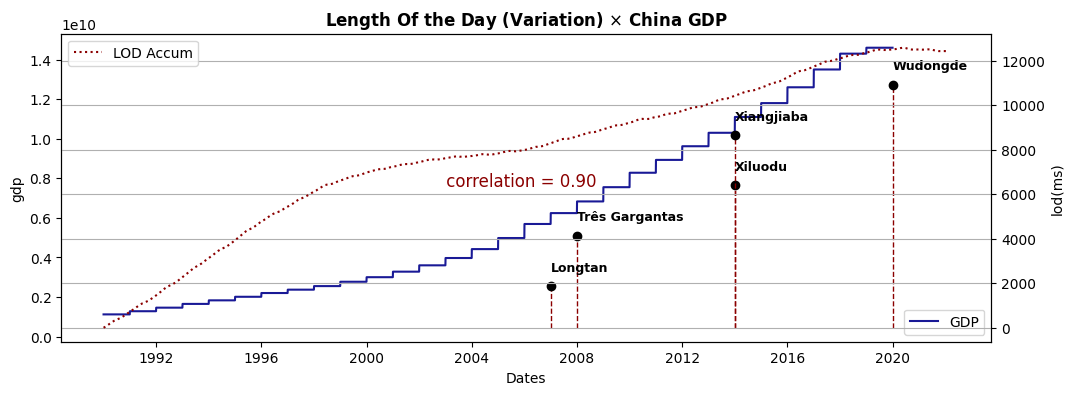

In [40]:
fig, ax = plt.subplots(figsize=(12,4))

sns.lineplot(x=df.index, y=df.gdp, alpha=0.9, label='GDP',ax=ax, color='darkblue')
ax.legend(loc='lower right')

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

i=1
for _, row in usinas_big.sort_values(['Ano de construção']).iterrows():
  ax.vlines(pd.to_datetime(row['Ano de construção']),ymin,ymax/(len(usinas_big)+1)*i,lw=1,linestyle='--',color='darkred')
  ax.plot(pd.to_datetime(row['Ano de construção']),ymax/(len(usinas_big)+1)*i,'ok')
  ax.text(pd.to_datetime(row['Ano de construção']),ymax/(len(usinas_big)+1)*i+ymax/20,row.Nome,c='k',weight='bold',fontsize=9)
  i=i+1

correlation = df.gdp.corr(df['lod(ms)'].cumsum())
x_center = xmin + (xmax - xmin) / 2
y_center = ymin + (ymax - ymin) / 2

ax.text(x_center, y_center, f'         correlation = {correlation:.2f}', ha='center', va='center', fontsize=12, color='darkred')

ax2 = ax.twinx()
sns.lineplot(x=df.index, y=df['lod(ms)'].cumsum(),label='LOD Accum',ax=ax2,color='darkred',linestyle=':')

ax.set_title('Length Of the Day (Variation) $\\times$ China GDP',weight='bold')
ax.set_xlabel('Dates')

plt.grid()
plt.show()

#### Salve sua resposta com a figura aqui. Basta existir o figura `fig` e executar a célula abaixo.

In [26]:
if 'fig' in locals():
  if isinstance(fig, plt.Figure):
    fig.savefig('q7.png')
    Q7 = fig

## Respostas Finais

In [27]:
#@markdown Execute para gerar e verificar suas respostas
import pickle
import numpy as np
import pandas as pd

if 'Q7' not in locals():
  Q7 = None

example_dict = {
    'Q1': Q1,
    'Q2': Q2,
    'Q3': Q3,
    'Q4': Q4,
    'Q5': Q5,
    'Q6': Q6,
    'Q7': Q7
}

# Define the filename with .pkl extension
filename = 'PSUB_' + Nome.replace(' ','_') + '_' + RA.replace('.','') + '.pkl'

# Serialize the dictionary to a pickle file
with open(filename, 'wb') as f:
      pickle.dump(example_dict, f)

from IPython.display import display, HTML

# display(HTML('<span style="font-family: Georgia; font-size: 24px; color: blue;">Respostas</span>'))
display(HTML('<span style="font-size: 24px; color: blue;">Respostas</span>'))
print()
for key, value in example_dict.items():
  if not isinstance(value, dict):
    print(f'{key}: {value}')
    print()
  else:
    print(f'{key}')
    for key2, value2 in value.items():
      print(f'{key2}: {value2}')
    print()
  print()

print()
display(HTML('<span style="font-size: 14px; color: blue;">Respostas salvas com sucesso em:</span>'))
print()
fname = f'<span style="font-size: 14px; color: blue;"><strong>{filename}</strong></span>'
display(HTML(fname))


Q1
Q1A. p =: 3
Q1B. d =: 2
Q1C. q =: 2


Q2
Q2A. AIC =: -1730.633
Q2B. RMSE =: 0.0609
Q2C. MAPE =: 0.3294
Q2D. params:: ma.L1 = 1.0575, ma.L2 = 0.4202, sigma2 = 0.0036; (OU ma.L1 = 0.7554, ma.L2 = 0.3255, sigma2 = 0.0035;)


Q3
Q3A. (p,d,q) =: (0,2,2)
Q3B. AIC =: -1735.907
Q3C. y(Jan 2030) =: 2440.15
Q3D. resposta:: Não. A diferença do AIC também é pequena. Como esperado coeficientes excluídos, sendo não significativos, não trazem diferença significativa nos resultados da predição.


Q4
Q4A. teste =: mannwhitneyu()
Q4B. p-value =: 0.00025
Q4C. resposta: : sim
Q4D. resposta: : keyboard, p-value = 0.087


Q5
Q5A. Sua pergunta =: O Gênero influencia na Frequência que o sujeito usa jogos de computador? 
Q5B. Variáveis envolvidas =: df_pre_games_Q: ['Gênero'] e ['Frequência que usa jogos de computador']
Q5C. p-value = : 0.0073
Q5D. Sua resposta: : Sim, o Gênero influencia na Frequência que o sujeito usa jogos de computador.


Q6
Q6A. teste =: stats.f_oneway
Q6B. p-value =: 0.2839
Q6C. resp

In [28]:
#@markdown Execute para fazer o download do arquivo com suas respostas
from google.colab import files
files.download(filename)


fname = f'<span style="font-size: 14px; color: blue;">Salve o arquivo {filename} para download.</strong></span>'
display(HTML(fname))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>